# AG-HYPOPT · Trial 02

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

The registry now holds one trial: **trial_01** (`w1_2d`, sigma_weight 0.409) -> objective **0.0895**
(+/- 0.0325), no divergences. That is ~0.009 *worse* than the frozen reference, the KDE control at
**0.080328**, so the first bandwidth-free alternative has not beaten the control. Its error sat in the
low-count mu channel: 1nW Trans05 collapsed (mu -36.5 %, gamma -61 %), 1nW Trans20 overshot mu by +65.9 %,
and the high-T cells were low on mu by 27-44 %, while gamma was good at high T.

Nothing else has run yet; the campaign is still in its `uniform` exploration phase. Frozen per trial:
exp5 schedule, exp7 bandwidth (rule `target`, h_f 4.0, h_s 3.6745), exp6 gamma_rel_cap 0.10736. The
two knobs are `loss_family` and `sigma_weight`; the campaign's aim is to test whether the loss *form*
beats the KDE NLL on the same scale-normalized footing.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_02'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (1/5 trials)
ID |     ei | params
 1 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.2984911434141233}
 2 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.8142257405942803}
 3 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.600100525965654}
 4 |      - | {"loss_family": "kde", "sigma_weight": 0.7285605268117946}
 5 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.05514662733306819}
 6 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.2749693679060381}
 7 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.562265662780428}
 8 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.15006226330533612}
 9 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.6692972985745202}
10 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.4227846732701278}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

One data point exists: trial_01 (`w1_2d`, sw 0.409) -> 0.0895, worse than the KDE control (0.0803).
The phase is still `uniform` (1/5), so this is exploration, not exploitation. The priority now is to
get a first reading on each of the other families rather than to fine-tune `sigma_weight` around the
4-D loss.

Scanning the table: the `w1_2d` draws (2, 6, 7) and `cvm_fwhm` (1, 5) are less useful - `w1_2d` already
has a point and `cvm_fwhm` is an FWHM-only control; `kde` (4) is the control and would just re-anchor
0.0803; `mmd_2d` (8) sits at a very low sw (0.150); `w1_fwhm` (9) drops the sigma link. The two
`energy_2d` draws (3 and 10) are the natural next family (a second bandwidth-free 2-D discrepancy, so it
is directly comparable to trial_01). Candidate 10 has sw 0.423, nearly identical to trial_01's 0.409,
which keeps `sigma_weight` effectively fixed and makes the comparison **isolate the loss form**.

I choose candidate 10.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 10             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'energy_2d', 'sigma_weight': 0.4227846732701278}
Running  1nW Trans05 ... 

μ 9.39 -> 6.26 | γ 8.5 -> 2.74 | NLL 55.03


Running  1nW Trans20 ... 

μ 17.32 -> 26.77 | γ 8.5 -> 5.23 | NLL 6.40


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 60.97 | γ 14.1 -> 13.81 | NLL 5.39


Running 3nW Trans100 ... 

μ 175.71 -> 94.59 | γ 14.1 -> 13.57 | NLL 4.35



Total: 7.4 min


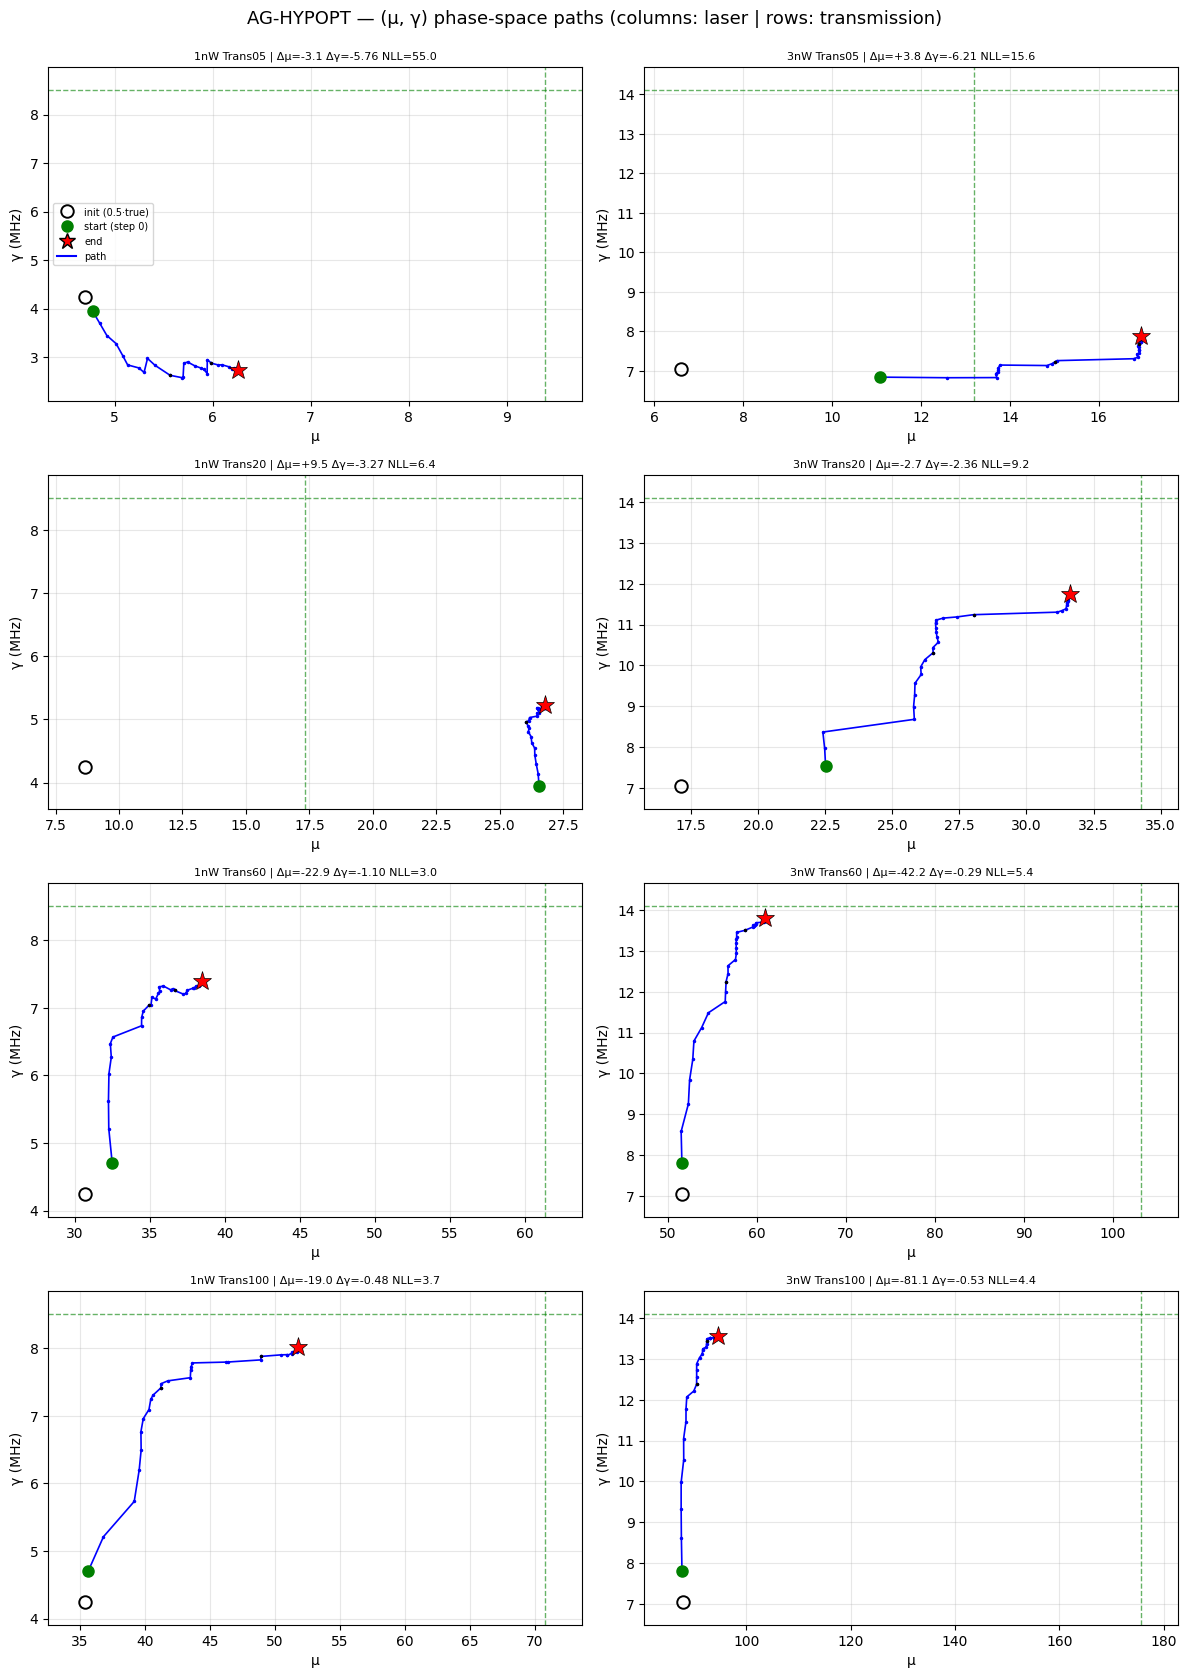

trial finished in 7.4 min
objective = 0.0996 ± 0.0318
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.26   -33.3 |     8.50    2.74   -67.8
1nW Trans20       17.32   26.77   +54.6 |     8.50    5.23   -38.5
1nW Trans60       61.37   38.51   -37.3 |     8.50    7.40   -12.9
1nW Trans100       70.82   51.78   -26.9 |     8.50    8.02    -5.6
3nW Trans05       13.20   16.95   +28.4 |    14.10    7.89   -44.0
3nW Trans20       34.28   31.61    -7.8 |    14.10   11.74   -16.7
3nW Trans60      103.20   60.97   -40.9 |    14.10   13.81    -2.1
3nW Trans100      175.71   94.59   -46.2 |    14.10   13.57    -3.7

weighted objective (T-graded, cap=1.0) = 0.0996 | diverged cells: 0
μ: RMSE 34.222 (rel 36.9%, bias -19.731) | γ: RMSE 3.350 (rel 32.6%, bias -2.499)


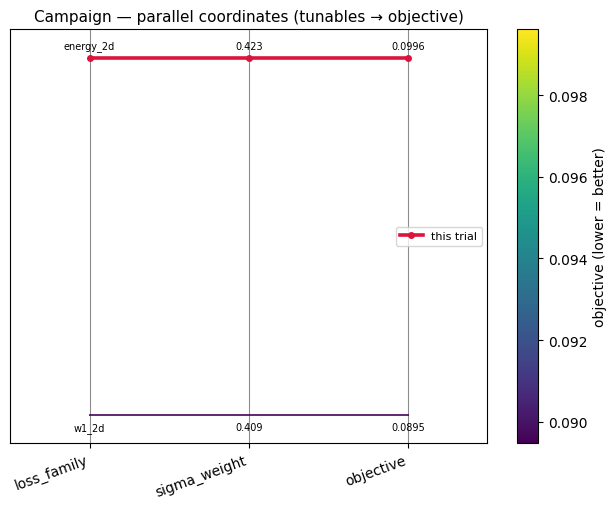

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'energy_2d', sigma_weight: 0.4228}` (candidate 10). Trial
time 7.4 min, objective **0.0996 +/- 0.0318**, **0 diverged cells**. Compared with trial_01 (`w1_2d`,
sw 0.409 -> 0.0895) at a nearly identical `sigma_weight`, the energy distance is **worse by 0.010**:
so far both bandwidth-free 2-D families trail the KDE control (0.0803).

**Per-cell behaviour.** No blow-ups; the error is again concentrated at low count, and this time it
is the **gamma** channel that is clearly damaged (systematic undershoot):

- 1nW Trans05: mu -33.3 %, gamma 8.5 -> 2.74 (**-67.8 %**) - gamma collapses to a third of truth.
- 1nW Trans20: mu +54.6 %, gamma -38.5 % (vs trial_01: mu +65.9 %, gamma -31.2 %).
- 1nW Trans60 / Trans100: mu -37.3 % / -26.9 %, gamma -12.9 % / -5.6 %.
- 3nW Trans05 / Trans20: mu +28.4 % / -7.8 %, gamma -44.0 % / -16.7 % (gamma much worse than trial_01's
  -31.5 % / -7.7 %).
- 3nW Trans60 / Trans100: mu -40.9 % / -46.2 %, gamma -2.1 % / -3.7 %.

**Aggregates.** mu: RMSE 34.22 (rel 36.9 %), bias -19.73; gamma: RMSE 3.35 (rel 32.6 %), bias -2.50
(both worse than trial_01's mu 32.3 / gamma 2.64). So relative to `w1_2d` the energy form is a bit worse
on mu and clearly worse on gamma, with gamma low in every low-count cell.

**Summary:** `energy_2d` at sw 0.423 reaches objective 0.0996, worse than both the KDE control (0.0803)
and trial_01's `w1_2d` (0.0895), with no divergences and a systematic low-count gamma undershoot.
**Key insight:** The energy distance is stable but undershoots gamma in the low-count cells, so as a
loss form it is currently the weakest of the three tested.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'energy_2d (sigma_weight 0.4228) reaches objective 0.0996, worse than trial_01 w1_2d (0.0895) and the KDE control (0.0803), no divergences, with a systematic low-count gamma undershoot.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The energy distance is stable but undershoots gamma in the low-count cells, making it the weakest loss form tested so far.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_02 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_03.ipynb. Open it and follow its cells from the top.
